In [1]:
!pip install -q scikit-image scikit-learn opencv-python kagglehub

In [77]:
import os
import kagglehub
import shutil
import pandas as pd

from sklearn.model_selection import train_test_split

import numpy as np
import cv2
from skimage.feature import local_binary_pattern

from sklearn.preprocessing import LabelEncoder

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# API TOKEN beállítása

os.environ['KAGGLE_API_TOKEN'] = "YOUR_API_TOKEN"

In [4]:
# Dataset letöltése

download_path = kagglehub.dataset_download("mehmoodsheikh/fairface-dataset")
print("Dataset cache útvonal:", download_path)

Using Colab cache for faster access to the 'fairface-dataset' dataset.
Dataset cache útvonal: /kaggle/input/fairface-dataset


In [104]:
# Útvonalak beállítása

DATASET_ROOT  = "/kaggle/input/fairface-dataset/FairFace"

TRAIN_DIR_PATH = os.path.join(DATASET_ROOT , "train")
VAL_DIR_PATH = os.path.join(DATASET_ROOT , "val")

TRAIN_CSV_PATH = os.path.join(DATASET_ROOT , "fairface_label_train.csv")
VAL_CSV_PATH = os.path.join(DATASET_ROOT , "fairface_label_val.csv")

In [30]:
# Adatok ellenőrzése

train_count = len([f for f in os.listdir(TRAIN_DIR_PATH)])
val_count = len([f for f in os.listdir(VAL_DIR_PATH)])

print("Train képek száma:", train_count)
print("Validation képek száma:", val_count)

Train képek száma: 86744
Validation képek száma: 10954


In [31]:
train_labels = pd.read_csv(TRAIN_CSV_PATH)
val_labels = pd.read_csv(VAL_CSV_PATH)

print("Train csv sorok:", len(train_labels))
print("Val csv sorok:", len(val_labels))

Train csv sorok: 86744
Val csv sorok: 10954


In [32]:
# A tanító halmazból a felhasználni kívánt képek (1000 db) kiválasztása

df = pd.read_csv(TRAIN_CSV_PATH)
print(df.head())
print("\nOszlopok:", df.columns.tolist())
print("\nMinták száma:", len(df))

          file    age  gender        race  service_test
0  train/1.jpg  50-59    Male  East Asian          True
1  train/2.jpg  30-39  Female      Indian         False
2  train/3.jpg    3-9  Female       Black         False
3  train/4.jpg  20-29  Female      Indian          True
4  train/5.jpg  20-29  Female      Indian          True

Oszlopok: ['file', 'age', 'gender', 'race', 'service_test']

Minták száma: 86744


In [33]:
DROP_AGES = ["0-2", "60-69", "more than 70"]

df = df[~df["age"].isin(DROP_AGES)].copy()
df = df.reset_index(drop=True)

# service_test oszlopot eldobjuk
if "service_test" in df.columns:
    df = df.drop(columns=["service_test"])

print("Szűrés utáni elemszám:", len(df))
print()
print(df["age"].value_counts().sort_index())

Szűrés utáni elemszám: 81331

age
10-19     9103
20-29    25598
3-9      10408
30-39    19250
40-49    10744
50-59     6228
Name: count, dtype: int64


In [105]:
# képfájlok teljes elérési útja

def make_full_path(file_value, image_root):
    file_value = str(file_value)
    file_value = file_value.replace("\\", "/")
    if file_value.startswith("train/"):
        file_value = file_value[len("train/"):]
    return os.path.join(image_root, file_value)

df["image_path"] = df["file"].apply(lambda x: make_full_path(x, TRAIN_DIR_PATH))

print(df[["file", "image_path"]].head())

missing = (~df["image_path"].apply(os.path.exists)).sum()
print("\nHiányzó fájlok száma:", missing)

          file                                         image_path
0  train/1.jpg  /kaggle/input/fairface-dataset/FairFace/train/...
1  train/2.jpg  /kaggle/input/fairface-dataset/FairFace/train/...
2  train/3.jpg  /kaggle/input/fairface-dataset/FairFace/train/...
3  train/4.jpg  /kaggle/input/fairface-dataset/FairFace/train/...
4  train/5.jpg  /kaggle/input/fairface-dataset/FairFace/train/...

Hiányzó fájlok száma: 0


In [106]:
# 1000 minta kiválasztása

RANDOM_SEED = 42
N_SAMPLES = 1000

df_sample = df.sample(n=N_SAMPLES, random_state=RANDOM_SEED).reset_index(drop=True)

print("Kiválasztott minták száma:", len(df_sample))
print()
print(df_sample.head())

Kiválasztott minták száma: 1000

              file    age  gender             race  \
0   train/3574.jpg    3-9  Female            Black   
1  train/32408.jpg  40-49  Female           Indian   
2  train/57368.jpg  40-49  Female       East Asian   
3  train/28528.jpg    3-9  Female  Southeast Asian   
4  train/20207.jpg  30-39    Male   Middle Eastern   

                                          image_path  
0  /kaggle/input/fairface-dataset/FairFace/train/...  
1  /kaggle/input/fairface-dataset/FairFace/train/...  
2  /kaggle/input/fairface-dataset/FairFace/train/...  
3  /kaggle/input/fairface-dataset/FairFace/train/...  
4  /kaggle/input/fairface-dataset/FairFace/train/...  


In [48]:
# Címkeeloszlások ellenőrzése

print("Gender eloszlás:")
print(df_sample["gender"].value_counts())
print()

print("Race eloszlás:")
print(df_sample["race"].value_counts())
print()

print("Age eloszlás:")
print(df_sample["age"].value_counts().sort_index())

Gender eloszlás:
gender
Male      505
Female    495
Name: count, dtype: int64

Race eloszlás:
race
White              188
Latino_Hispanic    160
East Asian         150
Black              141
Indian             137
Southeast Asian    117
Middle Eastern     107
Name: count, dtype: int64

Age eloszlás:
age
10-19    102
20-29    317
3-9      139
30-39    243
40-49    131
50-59     68
Name: count, dtype: int64


In [50]:
from sklearn.model_selection import train_test_split

# csak race alapján stratifikálunk
stratify_col = df_sample["race"]

# először train vs temp (70% / 30%)
df_train, df_temp = train_test_split(
    df_sample,
    test_size=0.30,
    random_state=RANDOM_SEED,
    stratify=stratify_col
)

# majd temp -> val és test (15% / 15%)
df_val, df_test = train_test_split(
    df_temp,
    test_size=0.50,
    random_state=RANDOM_SEED,
    stratify=df_temp["race"]
)

print("Train:", len(df_train))
print("Val:", len(df_val))
print("Test:", len(df_test))

Train: 700
Val: 150
Test: 150


In [55]:
print("TRAIN")
print("\nGender:")
print(df_train["gender"].value_counts(normalize=True))
print("\nRace:")
print(df_train["race"].value_counts(normalize=True))
print("\nAge:")
print(df_train["age"].value_counts(normalize=True).sort_index())
print()

print("\n\nVAL")
print("\nGender:")
print(df_val["gender"].value_counts(normalize=True))
print("\nRace:")
print(df_val["race"].value_counts(normalize=True))
print("\nAge:")
print(df_val["age"].value_counts(normalize=True).sort_index())
print()

print("\n\nTEST")
print("\nGender:")
print(df_test["gender"].value_counts(normalize=True))
print("\nRace:")
print(df_test["race"].value_counts(normalize=True))
print("\nAge:")
print(df_test["age"].value_counts(normalize=True).sort_index())

TRAIN

Gender:
gender
Male      0.518571
Female    0.481429
Name: proportion, dtype: float64

Race:
race
White              0.187143
Latino_Hispanic    0.160000
East Asian         0.150000
Black              0.141429
Indian             0.137143
Southeast Asian    0.117143
Middle Eastern     0.107143
Name: proportion, dtype: float64

Age:
age
10-19    0.098571
20-29    0.321429
3-9      0.142857
30-39    0.241429
40-49    0.132857
50-59    0.062857
Name: proportion, dtype: float64



VAL

Gender:
gender
Female    0.52
Male      0.48
Name: proportion, dtype: float64

Race:
race
White              0.193333
Latino_Hispanic    0.160000
East Asian         0.146667
Black              0.140000
Indian             0.140000
Southeast Asian    0.113333
Middle Eastern     0.106667
Name: proportion, dtype: float64

Age:
age
10-19    0.093333
20-29    0.333333
3-9      0.133333
30-39    0.233333
40-49    0.106667
50-59    0.100000
Name: proportion, dtype: float64



TEST

Gender:
gender
Female    0.5

In [57]:
# LBP feature extraction

# LBP paraméterek
LBP_RADIUS = 2
LBP_N_POINTS = 8 * LBP_RADIUS
LBP_METHOD = "uniform"

# uniform LBP esetén a binszám tipikusan P + 2
N_BINS = LBP_N_POINTS + 2

USE_CLAHE = True

In [58]:
# LBP segédfüggvények

def preprocess_image_for_lbp(image_path, use_clahe=True):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise ValueError(f"Nem sikerült betölteni a képet: {image_path}")

    # opcionális kontrasztjavítás
    if use_clahe:
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        img = clahe.apply(img)

    return img

def extract_lbp_histogram(image_gray):
    lbp = local_binary_pattern(
        image_gray,
        P=LBP_N_POINTS,
        R=LBP_RADIUS,
        method=LBP_METHOD
    )

    hist, _ = np.histogram(
        lbp.ravel(),
        bins=np.arange(0, N_BINS + 1),
        range=(0, N_BINS)
    )

    hist = hist.astype("float32")
    hist /= (hist.sum() + 1e-8)  # normalizálás

    return hist

def extract_features_from_path(image_path, use_clahe=True):
    img_gray = preprocess_image_for_lbp(image_path, use_clahe=use_clahe)
    features = extract_lbp_histogram(img_gray)
    return features

In [59]:
# Feature mátrixok előállítása

def build_feature_matrix(df_part, use_clahe=True):
    X = []
    bad_paths = []

    for path in df_part["image_path"].tolist():
        try:
            feat = extract_features_from_path(path, use_clahe=use_clahe)
            X.append(feat)
        except Exception:
            bad_paths.append(path)
            X.append(np.zeros(N_BINS, dtype=np.float32))

    X = np.array(X, dtype=np.float32)
    return X, bad_paths

X_train, bad_train = build_feature_matrix(df_train, use_clahe=USE_CLAHE)
X_val, bad_val = build_feature_matrix(df_val, use_clahe=USE_CLAHE)
X_test, bad_test = build_feature_matrix(df_test, use_clahe=USE_CLAHE)

print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("X_test shape:", X_test.shape)

print("Hibás train képek:", len(bad_train))
print("Hibás val képek:", len(bad_val))
print("Hibás test képek:", len(bad_test))

X_train shape: (700, 18)
X_val shape: (150, 18)
X_test shape: (150, 18)
Hibás train képek: 0
Hibás val képek: 0
Hibás test képek: 0


In [69]:
# Label encoding

# Gender
le_gender = LabelEncoder()
y_train_gender = le_gender.fit_transform(df_train["gender"])
y_val_gender = le_gender.transform(df_val["gender"])
y_test_gender = le_gender.transform(df_test["gender"])

# Race
le_race = LabelEncoder()
y_train_race = le_race.fit_transform(df_train["race"])
y_val_race = le_race.transform(df_val["race"])
y_test_race = le_race.transform(df_test["race"])

# Age
le_age = LabelEncoder()
y_train_age = le_age.fit_transform(df_train["age"])
y_val_age = le_age.transform(df_val["age"])
y_test_age = le_age.transform(df_test["age"])

In [84]:
# train + validation összevonása a végső tanításhoz
X_trainval = np.vstack([X_train, X_val])

y_trainval_gender = np.concatenate([y_train_gender, y_val_gender])
y_trainval_race = np.concatenate([y_train_race, y_val_race])
y_trainval_age = np.concatenate([y_train_age, y_val_age])

In [85]:
def make_svm_pipeline(C=1.0, kernel="rbf", gamma="scale", class_weight=None):
    return Pipeline([
        ("scaler", StandardScaler()),
        ("svm", SVC(
            C=C,
            kernel=kernel,
            gamma=gamma,
            class_weight=class_weight
        ))
    ])

# kipróbálandó hiperparaméterek
param_grid = [
    {"C": 0.1, "kernel": "linear", "class_weight": None},
    {"C": 1.0, "kernel": "linear", "class_weight": None},
    {"C": 10.0, "kernel": "linear", "class_weight": None},

    {"C": 0.1, "kernel": "linear", "class_weight": "balanced"},
    {"C": 1.0, "kernel": "linear", "class_weight": "balanced"},
    {"C": 10.0, "kernel": "linear", "class_weight": "balanced"},

    {"C": 0.1, "kernel": "rbf", "gamma": "scale", "class_weight": None},
    {"C": 1.0, "kernel": "rbf", "gamma": "scale", "class_weight": None},
    {"C": 10.0, "kernel": "rbf", "gamma": "scale", "class_weight": None},

    {"C": 0.1, "kernel": "rbf", "gamma": "auto", "class_weight": None},
    {"C": 1.0, "kernel": "rbf", "gamma": "auto", "class_weight": None},
    {"C": 10.0, "kernel": "rbf", "gamma": "auto", "class_weight": None},

    {"C": 0.1, "kernel": "rbf", "gamma": "scale", "class_weight": "balanced"},
    {"C": 1.0, "kernel": "rbf", "gamma": "scale", "class_weight": "balanced"},
    {"C": 10.0, "kernel": "rbf", "gamma": "scale", "class_weight": "balanced"},

    {"C": 0.1, "kernel": "rbf", "gamma": "auto", "class_weight": "balanced"},
    {"C": 1.0, "kernel": "rbf", "gamma": "auto", "class_weight": "balanced"},
    {"C": 10.0, "kernel": "rbf", "gamma": "auto", "class_weight": "balanced"},
]

In [86]:
# Hiperparaméter optimalizáló és a végső modellt tanító függvény

def tune_svm_with_validation(
    X_train, y_train,
    X_val, y_val,
    X_trainval, y_trainval,
    param_grid,
    model_name="Model"
):
    results = []
    best_score = -1.0
    best_params = None
    best_model = None

    print(f"\n===== Hiperparaméter keresés: {model_name} =====")

    for i, params in enumerate(param_grid, 1):
        clf = make_svm_pipeline(**params)
        clf.fit(X_train, y_train)

        y_val_pred = clf.predict(X_val)
        val_acc = accuracy_score(y_val, y_val_pred)

        result = params.copy()
        result["val_accuracy"] = val_acc
        results.append(result)

        print(f"{i:02d}. params={params} -> val_accuracy={val_acc:.4f}")

        if val_acc > best_score:
            best_score = val_acc
            best_params = params
            best_model = clf

    print(f"\nLegjobb validációs accuracy ({model_name}): {best_score:.4f}")
    print("Legjobb paraméterek:", best_params)

    # végső modell: train + val adaton újratanítva a legjobb paraméterekkel
    final_clf = make_svm_pipeline(**best_params)
    final_clf.fit(X_trainval, y_trainval)

    results_df = pd.DataFrame(results).sort_values("val_accuracy", ascending=False).reset_index(drop=True)

    return final_clf, best_params, best_score, results_df

In [89]:
# SVM végső modellek tanítása

gender_clf, best_params_gender, best_val_acc_gender, tuning_results_gender = tune_svm_with_validation(
    X_train, y_train_gender,
    X_val, y_val_gender,
    X_trainval, y_trainval_gender,
    param_grid,
    model_name="Gender"
)

race_clf, best_params_race, best_val_acc_race, tuning_results_race = tune_svm_with_validation(
    X_train, y_train_race,
    X_val, y_val_race,
    X_trainval, y_trainval_race,
    param_grid,
    model_name="Race"
)

age_clf, best_params_age, best_val_acc_age, tuning_results_age = tune_svm_with_validation(
    X_train, y_train_age,
    X_val, y_val_age,
    X_trainval, y_trainval_age,
    param_grid,
    model_name="Age"
)

print("\nMindhárom végső modell betanítva a legjobb paraméterekkel (train+val adaton).")


===== Hiperparaméter keresés: Gender =====
01. params={'C': 0.1, 'kernel': 'linear', 'class_weight': None} -> val_accuracy=0.5733
02. params={'C': 1.0, 'kernel': 'linear', 'class_weight': None} -> val_accuracy=0.5333
03. params={'C': 10.0, 'kernel': 'linear', 'class_weight': None} -> val_accuracy=0.5467
04. params={'C': 0.1, 'kernel': 'linear', 'class_weight': 'balanced'} -> val_accuracy=0.5600
05. params={'C': 1.0, 'kernel': 'linear', 'class_weight': 'balanced'} -> val_accuracy=0.5467
06. params={'C': 10.0, 'kernel': 'linear', 'class_weight': 'balanced'} -> val_accuracy=0.5600
07. params={'C': 0.1, 'kernel': 'rbf', 'gamma': 'scale', 'class_weight': None} -> val_accuracy=0.5267
08. params={'C': 1.0, 'kernel': 'rbf', 'gamma': 'scale', 'class_weight': None} -> val_accuracy=0.5200
09. params={'C': 10.0, 'kernel': 'rbf', 'gamma': 'scale', 'class_weight': None} -> val_accuracy=0.4867
10. params={'C': 0.1, 'kernel': 'rbf', 'gamma': 'auto', 'class_weight': None} -> val_accuracy=0.5267
11. pa

In [98]:
# Kiértékelő függvény

def evaluate_model(clf, X, y_true, label_encoder, model_name="Model"):
    y_pred = clf.predict(X)

    acc = accuracy_score(y_true, y_pred)
    print(f"===== {model_name} =====")
    print(f"Accuracy: {acc:.4f}")
    print()

    print(classification_report(
        y_true,
        y_pred,
        target_names=label_encoder.classes_,
        digits=4,
        zero_division=0
    ))

    cm = confusion_matrix(y_true, y_pred)
    return y_pred, cm, acc

In [99]:
# Test kiértékelés

y_test_pred_gender, cm_gender_test, acc_gender_test = evaluate_model(
    gender_clf, X_test, y_test_gender, le_gender, model_name="Gender - Test"
)

y_test_pred_race, cm_race_test, acc_race_test = evaluate_model(
    race_clf, X_test, y_test_race, le_race, model_name="Race - Test"
)

y_test_pred_age, cm_age_test, acc_age_test = evaluate_model(
    age_clf, X_test, y_test_age, le_age, model_name="Age - Test"
)

===== Gender - Test =====
Accuracy: 0.6267

              precision    recall  f1-score   support

      Female     0.7222    0.4875    0.5821        80
        Male     0.5729    0.7857    0.6627        70

    accuracy                         0.6267       150
   macro avg     0.6476    0.6366    0.6224       150
weighted avg     0.6525    0.6267    0.6197       150

===== Race - Test =====
Accuracy: 0.2067

                 precision    recall  f1-score   support

          Black     0.2857    0.1905    0.2286        21
     East Asian     0.1364    0.1304    0.1333        23
         Indian     0.1875    0.1500    0.1667        20
Latino_Hispanic     0.2963    0.3333    0.3137        24
 Middle Eastern     0.0000    0.0000    0.0000        16
Southeast Asian     0.2000    0.0556    0.0870        18
          White     0.2000    0.4286    0.2727        28

       accuracy                         0.2067       150
      macro avg     0.1866    0.1841    0.1717       150
   weighted avg

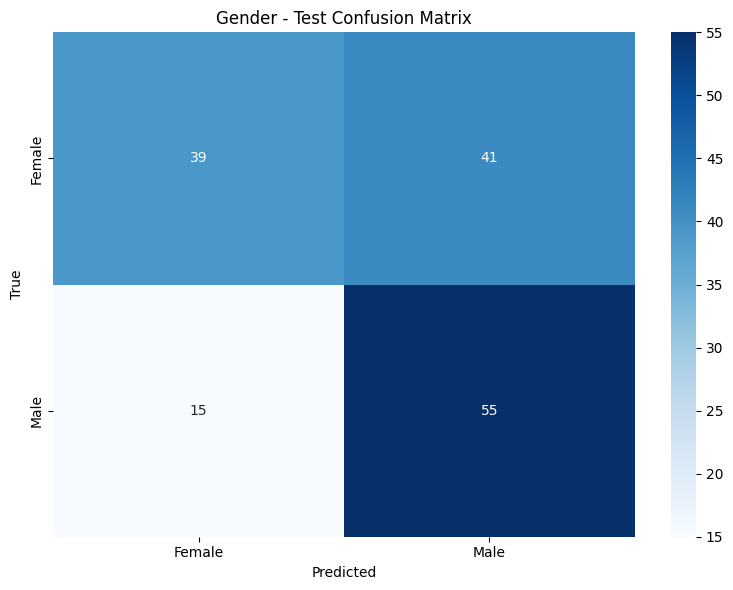

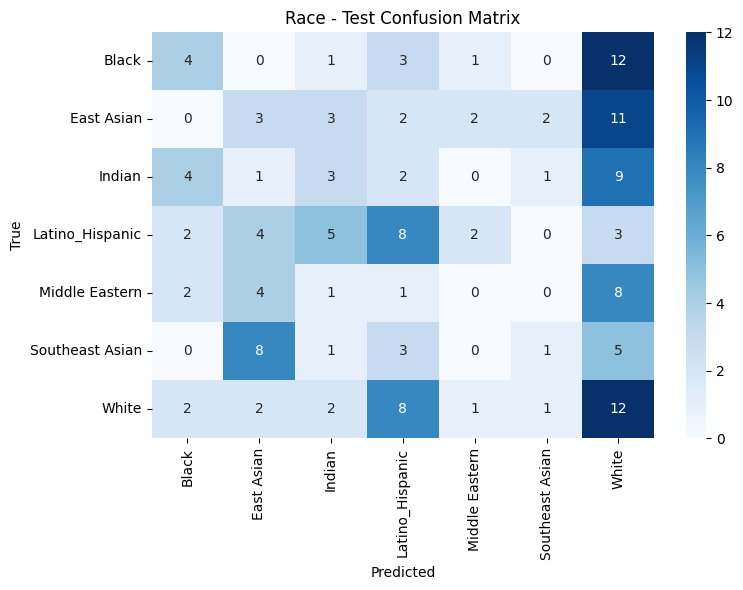

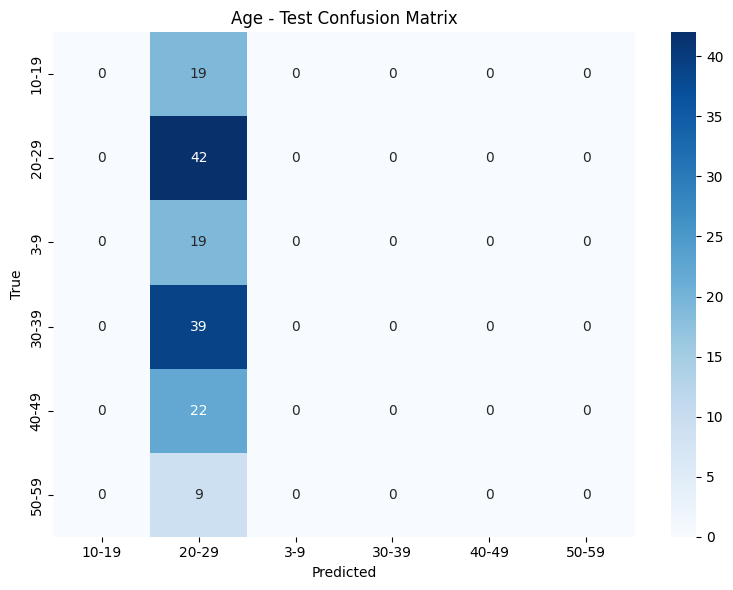

In [100]:
# konfúziós mátrixok kirajzolása

def plot_confusion_matrix(cm, class_names, title):
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()

plot_confusion_matrix(cm_gender_test, le_gender.classes_, "Gender - Test Confusion Matrix")
plot_confusion_matrix(cm_race_test, le_race.classes_, "Race - Test Confusion Matrix")
plot_confusion_matrix(cm_age_test, le_age.classes_, "Age - Test Confusion Matrix")

In [107]:
# eredmények összegzése

results_df = pd.DataFrame({
    "task": ["gender", "race", "age"],
    "best_val_accuracy": [best_val_acc_gender, best_val_acc_race, best_val_acc_age],
    "test_accuracy": [acc_gender_test, acc_race_test, acc_age_test],
    "best_params": [best_params_gender, best_params_race, best_params_age]
})

print(results_df)

     task  best_val_accuracy  test_accuracy  \
0  gender           0.573333       0.626667   
1    race           0.220000       0.206667   
2     age           0.333333       0.280000   

                                         best_params  
0  {'C': 0.1, 'kernel': 'linear', 'class_weight':...  
1  {'C': 1.0, 'kernel': 'rbf', 'gamma': 'scale', ...  
2  {'C': 0.1, 'kernel': 'linear', 'class_weight':...  
